# Experiment: Q(1) Opposite Parity Retention

Objective:
- Compare the Q(1) F=1, mF=+1 -> F'=0 optical Bloch simulation with and without retaining the closest excited-state opposite-parity dressed level.
- Use E = 200 V/cm along Z, X-polarized light, 60 mW spread over a 2 cm x 2 cm flat-top beam, and a 184 m/s molecular velocity.
- Keep the default path backwards compatible by making the retained-level system an explicit opt-in case.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as cst
import sympy as smp

plt.rcParams.update({"font.size": 14})

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.lindblad.solve import solve_lindblad
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)


## Plan

- Build the standard transition-derived OBE system and the opt-in retained-opposite-parity system.
- Confirm which excited levels are retained and list nearby J'=1 B-state offsets at 200 V/cm.
- Set the optical Rabi rate from the requested flat-top beam power and the system's main coupling.
- Start all population in the lowest X-state F=1, mF=+1 level and compare population evolution over one 2 cm beam crossing.
- Compare zero-transverse-velocity frequency scans and the convolution-based Doppler average.


In [2]:
transition = transitions.Q1_F1_1o2_F0

E_FIELD = np.array([0.0, 0.0, 200.0])  # V/cm, along Z
B_FIELD = np.array([0.0, 0.0, 1e-5])  # G, tiny quantization field
POWER = 60e-3  # W
BEAM_WX = 0.02  # m
BEAM_WY = 0.02  # m
VELOCITY = 184.0  # m/s
INTERACTION_LENGTH = 0.02  # m
T_END = INTERACTION_LENGTH / VELOCITY
SAVEAT = np.linspace(0.0, T_END, 401)
DETUNING_SCAN_MHZ = np.linspace(-80.0, 80.0, 161)
SCAN_SAVEAT = np.linspace(0.0, T_END, 801)
SCAN_THREADS = None  # None lets the Rust backend choose; set an int to cap cores.

TRANSVERSE_VELOCITY_SIGMA = 1.4  # m/s
OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

INTENSITY = power_to_intensity_rectangular_beam(POWER, BEAM_WX, BEAM_WY)

config = {
    "transition": "Q(1) F=1/2 -> F'=0",
    "electric_field_V_per_cm": E_FIELD.tolist(),
    "polarization": "X",
    "power_mW": POWER * 1e3,
    "beam_area_cm2": (BEAM_WX * 100) * (BEAM_WY * 100),
    "intensity_mW_per_cm2": INTENSITY * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "detuning_scan_MHz": [float(DETUNING_SCAN_MHZ[0]), float(DETUNING_SCAN_MHZ[-1])],
    "detuning_scan_points": int(DETUNING_SCAN_MHZ.size),
    "doppler_sigma_MHz": float(DOPPLER_SIGMA_MHZ),
    "optical_wavelength_nm": float(OPTICAL_WAVELENGTH_M * 1e9),
}
config


{'transition': "Q(1) F=1/2 -> F'=0",
 'electric_field_V_per_cm': [0.0, 0.0, 200.0],
 'polarization': 'X',
 'power_mW': 60.0,
 'beam_area_cm2': 4.0,
 'intensity_mW_per_cm2': 15.0,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'detuning_scan_MHz': [-80.0, 80.0],
 'detuning_scan_points': 161,
 'doppler_sigma_MHz': 5.136887066051542,
 'optical_wavelength_nm': 272.5385981818182}

## Level Offsets

The table below diagonalizes the full J'=1 B manifold with both parities included and reports offsets relative to the addressed Q(1) F'=0, P=+ dressed level. Frequencies are ordinary frequency offsets, not angular frequencies.


In [3]:
def _state_label(state: states.CoupledState) -> str:
    qn = state.largest
    f1 = smp.S(str(qn.F1), rational=True) if qn.F1 is not None else None
    parity = "+" if qn.P == 1 else "-"
    return f"J={qn.J}, F1={f1}, F={qn.F}, mF={qn.mF}, P={parity}"


def j1_b_level_offsets() -> list[dict[str, float | str]]:
    selector = states.QuantumSelector(
        electronic=states.ElectronicState.B,
        J=transition.J_excited,
        P=[transition.P_excited, -transition.P_excited],
    )
    approx_states = list(states.generate_coupled_states_B(selector))
    reduced = hamiltonian.generate_reduced_B_hamiltonian(
        approx_states,
        E=E_FIELD,
        B=B_FIELD,
        Jmin=transition.J_excited,
        Jmax=transition.J_excited + 2,
    )

    ref_idx = next(
        i
        for i, state in enumerate(reduced.QN_basis)
        if state.largest.F1 == transition.F1_excited
        and state.largest.F == transition.F_excited
        and state.largest.mF == 0
        and state.largest.P == transition.P_excited
    )
    ref_energy = float(np.real(reduced.H[ref_idx, ref_idx]))

    rows = []
    for i, state in enumerate(reduced.QN_basis):
        delta_mhz = (float(np.real(reduced.H[i, i])) - ref_energy) / (2 * np.pi * 1e6)
        rows.append(
            {
                "state": _state_label(state),
                "delta_MHz": delta_mhz,
                "abs_delta_MHz": abs(delta_mhz),
            }
        )
    return sorted(rows, key=lambda row: row["abs_delta_MHz"])


level_offsets = j1_b_level_offsets()
for row in level_offsets[:8]:
    print(f"{row['delta_MHz']:10.3f} MHz  {row['state']}")


     0.000 MHz  J=1, F1=1/2, F=0, mF=0, P=+
    15.420 MHz  J=1, F1=1/2, F=0, mF=0, P=-
   508.083 MHz  J=1, F1=1/2, F=1, mF=1, P=+
   508.083 MHz  J=1, F1=1/2, F=1, mF=-1, P=+
   585.503 MHz  J=1, F1=1/2, F=1, mF=0, P=+
   600.895 MHz  J=1, F1=1/2, F=1, mF=0, P=-
   656.427 MHz  J=1, F1=1/2, F=1, mF=1, P=-
   656.427 MHz  J=1, F1=1/2, F=1, mF=-1, P=-


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 9, 12, 13, 14, 15, 16, 17, 20, 21, 22, 23]. Overlaps: [0.41500601174809604, 0.4164450739381488, 0.4150060118998825, 0.4164450734906691, 0.40862521857583123, 0.40954106877453067, 0.453162005352115, 0.4533277015459543, 0.4531620065409425, 0.4533277021759541, 0.4086252185867712, 0.4095410687839238]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


## Build OBE Systems

The default system keeps the same retained levels as before. The opt-in system keeps the opposite-parity B-state partner as an explicit OBE level after the electric-field mixing calculation. Plot labels use `total X` for all retained ground-state population; they do not imply a same-J opposite-parity X ground state.


The scan systems use `qn_compact=True` to merge decay-only ground rotational manifolds while retaining the addressed and opposite-parity excited levels explicitly.


In [4]:
transition_selectors = couplings.generate_transition_selectors(
    transitions=[transition],
    polarizations=[[couplings.polarization_X]],
)

systems = {
    "default": lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True,
        E=E_FIELD,
        B=B_FIELD,
        method="matrix",
    ),
    "retained_B_opposite_parity": lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True,
        E=E_FIELD,
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
    ),
}
DISPLAY_LABELS = {
    "default": "default",
    "retained_B_opposite_parity": "retained P'=-",
}

for name, system in systems.items():
    retained = [
        _state_label(state)
        for state in system.excited
        if state.largest.J == transition.J_excited
        and state.largest.F1 == transition.F1_excited
        and state.largest.F == transition.F_excited
    ]
    print(
        f"{DISPLAY_LABELS[name]}: {len(system.QN)} total levels, retained F'=0 levels = {retained}"
    )


default: 15 total levels, retained F'=0 levels = ['J=1, F1=1/2, F=0, mF=0, P=+']
retained P'=-: 17 total levels, retained F'=0 levels = ['J=1, F1=1/2, F=0, mF=0, P=+', 'J=1, F1=1/2, F=0, mF=0, P=-']


## Simulation Helpers

The Hamiltonian convention uses the symbolic Rabi rate as the main transition's Rabi rate. For each OBE system, the main coupling is converted from beam power to that Rabi rate, and all detunings are left at zero so the laser is parked on the addressed transition.


In [5]:
def parameter_values(system: lindblad.OBESystem) -> tuple[LindbladParameters, float]:
    main_coupling = abs(system.couplings[0].main_coupling)
    rabi_rate = power_to_rabi_rectangular_beam(
        POWER,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )

    values = {str(symbol): 0.0 for symbol in system.H_symbolic.free_symbols}
    for symbol in system.coupling_symbols:
        values[str(symbol)] = rabi_rate
    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            values[str(symbol)] = 1.0

    params = LindbladParameters()
    for name, value in values.items():
        params.real(name, float(value))
    return params, rabi_rate


def initial_state_index(system: lindblad.OBESystem) -> int:
    candidates = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if (
            qn.electronic_state == states.ElectronicState.X
            and qn.J == transition.J_ground
            and qn.F == 1
            and qn.mF == 1
        ):
            candidates.append(idx)
    if not candidates:
        raise ValueError("Could not find an X-state F=1, mF=+1 initial state.")
    return min(candidates, key=lambda idx: float(np.real(system.H_int[idx, idx])))


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    rho0 = np.zeros((len(system.QN), len(system.QN)), dtype=np.complex128)
    idx = initial_state_index(system)
    rho0[idx, idx] = 1.0
    return rho0


def index_sets(system: lindblad.OBESystem) -> dict[str, list[int]]:
    ground = []
    ground_J1 = []
    ground_other = []
    excited = []
    addressed = []
    opposite = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if qn.electronic_state == states.ElectronicState.X:
            ground.append(idx)
        elif qn.electronic_state == states.ElectronicState.B:
            excited.append(idx)
            is_f0 = (
                qn.J == transition.J_excited
                and qn.F1 == transition.F1_excited
                and qn.F == transition.F_excited
                and qn.mF == 0
            )
            if is_f0 and qn.P == transition.P_excited:
                addressed.append(idx)
            if is_f0 and qn.P == -transition.P_excited:
                opposite.append(idx)
        if qn.electronic_state == states.ElectronicState.X:
            if qn.J == 1:
                ground_J1.append(idx)
            else:
                ground_other.append(idx)
    return {
        "ground": ground,
        "ground_J1": ground_J1,
        "ground_other": ground_other,
        "excited": excited,
        "addressed": addressed,
        "opposite": opposite,
    }


def simulate(system: lindblad.OBESystem) -> dict[str, object]:
    params, rabi_rate = parameter_values(system)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )

    rho0 = initial_density_matrix(system)

    result = solve_lindblad(
        prepared,
        rho0,
        (0.0, T_END),
        solver="dopri5",
        execution_mode="expanded_sparse",
        saveat=SAVEAT,
        dt=2e-9,
        reltol=1e-7,
        abstol=1e-9,
        output="populations",
        collect_stats=True,
    )
    return {
        "t": result.t,
        "populations": result.values,
        "rabi_rate": rabi_rate,
        "solver_stats": result.solver_stats,
        "indices": index_sets(system),
    }


## Run Comparison

This is the expensive cell. It stores population-only output at the requested beam-crossing times.


In [6]:
runs = {name: simulate(system) for name, system in systems.items()}

summary = {}
for name, run in runs.items():
    populations = run["populations"]
    indices = run["indices"]
    final = populations[-1]
    summary[name] = {
        "rabi_rate_MHz": run["rabi_rate"] / (2 * np.pi * 1e6),
        "final_ground": float(final[indices["ground"]].sum()),
        "final_excited": float(final[indices["excited"]].sum()),
        "final_addressed_F0": float(final[indices["addressed"]].sum()),
        "final_opposite_F0": float(final[indices["opposite"]].sum())
        if indices["opposite"]
        else 0.0,
    }
summary


{'default': {'rabi_rate_MHz': np.float64(0.25578467625417595),
  'final_ground': 0.9999860233843002,
  'final_excited': 1.3976615700513458e-05,
  'final_addressed_F0': 1.3976615700513458e-05,
  'final_opposite_F0': 0.0},
 'retained_B_opposite_parity': {'rabi_rate_MHz': np.float64(0.2551445738015092),
  'final_ground': 0.9999832185041397,
  'final_excited': 1.6781495862678376e-05,
  'final_addressed_F0': 1.3933817230406004e-05,
  'final_opposite_F0': 2.84767863227237e-06}}

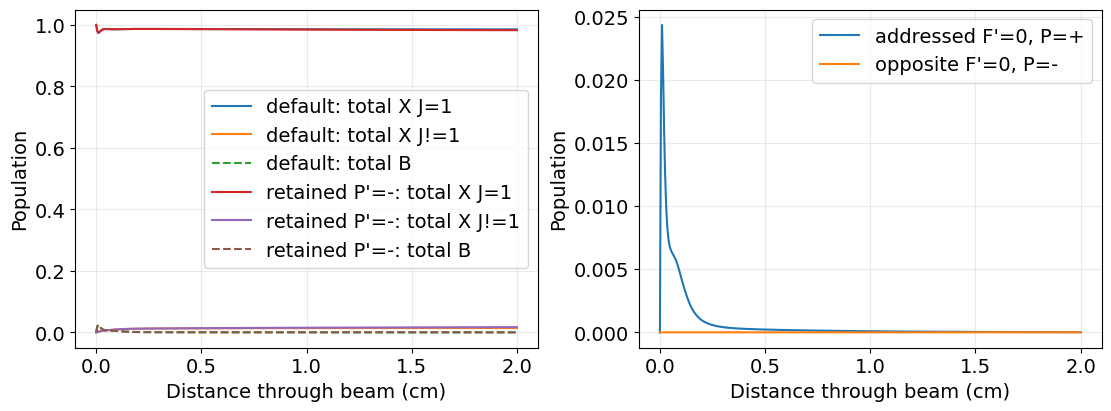

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for name, run in runs.items():
    z_cm = run["t"] * VELOCITY * 100
    pops = run["populations"]
    idx = run["indices"]
    label = DISPLAY_LABELS[name]
    axes[0].plot(z_cm, pops[:, idx["ground_J1"]].sum(axis=1), label=f"{label}: total X J=1")
    axes[0].plot(z_cm, pops[:, idx["ground_other"]].sum(axis=1), label=f"{label}: total X J!=1")
    axes[0].plot(z_cm, pops[:, idx["excited"]].sum(axis=1), "--", label=f"{label}: total B")

retained = runs["retained_B_opposite_parity"]
z_cm = retained["t"] * VELOCITY * 100
pops = retained["populations"]
idx = retained["indices"]
axes[1].plot(z_cm, pops[:, idx["addressed"]].sum(axis=1), label="addressed F'=0, P=+")
if idx["opposite"]:
    axes[1].plot(z_cm, pops[:, idx["opposite"]].sum(axis=1), label="opposite F'=0, P=-")

axes[0].set_xlabel("Distance through beam (cm)")
axes[0].set_ylabel("Population")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("Distance through beam (cm)")
axes[1].set_ylabel("Population")
axes[1].legend()
axes[1].grid(alpha=0.25)

## Frequency Scan

This scan keeps the Rabi rate fixed by the 60 mW beam and scans the laser detuning `δ0`. The y-axis is the expected number of scattered photons, computed as the Rust `photon_integral` output, ∫ Γ P_excited(t) dt, over the 2 cm beam crossing. `parallel=True` uses the Rust parallel grid path; set `SCAN_THREADS` above to an integer to cap the core count.


In [8]:
Q1_OPPOSITE_PARITY_OFFSET_MHZ = 15.420447886


def add_q1_level_markers(
    ax: plt.Axes,
    *,
    include_reference: bool = True,
    include_opposite: bool = True,
) -> None:
    if include_reference:
        ax.axvline(
            0.0,
            color="C2",
            lw=2.2,
            ls="-",
            alpha=0.95,
            label="_nolegend_",
            zorder=1,
        )
        ax.text(
            0.0,
            0.96,
            "P'=+\nF'=0",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            fontsize=10,
            color="C2",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "C2",
                "alpha": 0.9,
            },
            zorder=3,
        )

    if include_opposite:
        label_y = 0.82 if include_reference else 0.96
        ax.axvline(
            Q1_OPPOSITE_PARITY_OFFSET_MHZ,
            color="C3",
            lw=2.0,
            ls="--",
            alpha=0.9,
            label="_nolegend_",
            zorder=1,
        )
        ax.text(
            Q1_OPPOSITE_PARITY_OFFSET_MHZ,
            label_y,
            "P'=-\nF'=0",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            fontsize=10,
            color="C3",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "C3",
                "alpha": 0.9,
            },
            zorder=3,
        )


def side_legend(ax: plt.Axes, *, fontsize: int = 11, ncols: int = 1) -> None:
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
        fontsize=fontsize,
        ncols=ncols,
    )


def print_scan_timings(summary: dict[str, dict[str, object]], title: str) -> None:
    print(title)
    for name, row in summary.items():
        total_seconds = row.get("solver_total_seconds")
        label = DISPLAY_LABELS.get(name, name)
        if total_seconds is None:
            print(f"  {label}: solver time unavailable")
        else:
            print(f"  {label}: {float(total_seconds):.1f} s")


def photon_count_frequency_scan(
    system: lindblad.OBESystem,
    detuning_mhz: np.ndarray = DETUNING_SCAN_MHZ,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    params, rabi_rate = parameter_values(system)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    excited_indices = index_sets(system)["excited"]
    photon_integral_weights = [(int(idx), float(hamiltonian.Γ)) for idx in excited_indices]

    result = lindblad.grid_scan(
        prepared,
        initial_density_matrix(system),
        (0.0, T_END),
        scan={transition_selectors[0].δ: 2 * np.pi * 1e6 * detuning_mhz},
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="saveat",
        integral_weights=photon_integral_weights,
        saveat=SCAN_SAVEAT,
        dt=2e-9,
        reltol=1e-7,
        abstol=1e-9,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(detuning_mhz.size, -1)[:, -1]
    return {
        "detuning_MHz": detuning_mhz,
        "photons": photons,
        "rabi_rate": rabi_rate,
        "result": result,
    }


frequency_scans = {name: photon_count_frequency_scan(system) for name, system in systems.items()}
scan_summary = {}
for name, scan in frequency_scans.items():
    peak_idx = int(np.argmax(scan["photons"]))
    scan_summary[name] = {
        "peak_detuning_MHz": float(scan["detuning_MHz"][peak_idx]),
        "peak_photons": float(scan["photons"][peak_idx]),
        "rabi_rate_MHz": float(scan["rabi_rate"] / (2 * np.pi * 1e6)),
        "solver_total_seconds": scan["result"].solver_stats.get("total_seconds")
        if scan["result"].solver_stats is not None
        else None,
    }
print_scan_timings(scan_summary, "Frequency scan solver time")
scan_summary


Frequency scan solver time
  default: 1.3 s
  retained P'=-: 2.2 s


{'default': {'peak_detuning_MHz': -1.0,
  'peak_photons': 0.7418047573876446,
  'rabi_rate_MHz': 0.25578467625417595,
  'solver_total_seconds': 1.2979708999628201},
 'retained_B_opposite_parity': {'peak_detuning_MHz': -1.0,
  'peak_photons': 0.7408454677659446,
  'rabi_rate_MHz': 0.2551445738015092,
  'solver_total_seconds': 2.1911253000143915}}

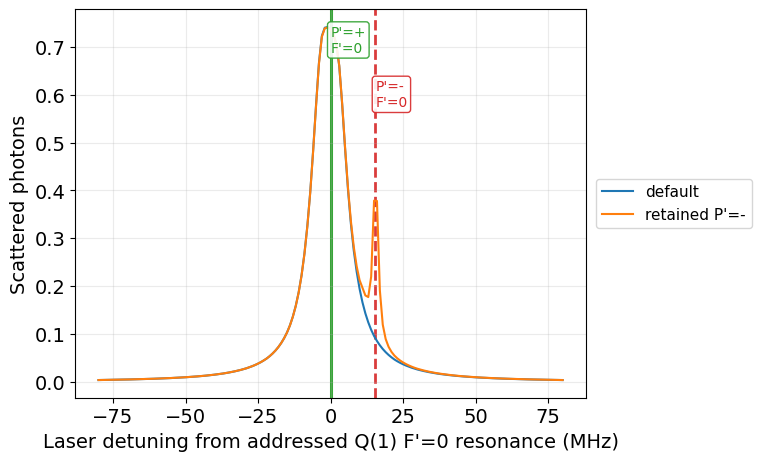

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)

for name, scan in frequency_scans.items():
    ax.plot(scan["detuning_MHz"], scan["photons"], label=DISPLAY_LABELS[name])

add_q1_level_markers(ax)
ax.set_xlabel("Laser detuning from addressed Q(1) F'=0 resonance (MHz)")
ax.set_ylabel("Scattered photons")
side_legend(ax)
ax.grid(alpha=0.25)


## Doppler averaging by convolution

For this scan the transverse velocity only shifts the effective laser detuning, so the Doppler-averaged photon curve can be computed as a Gaussian convolution of a fine zero-velocity frequency scan. This avoids solving one OBE system for every laser-detuning/velocity-node pair and gives smoother convergence for the narrow opposite-parity feature.

The solved detuning range is wider than the plotted range by several Doppler widths to keep convolution edge effects outside the visible `-80..80 MHz` window.


In [10]:
CONV_PLOT_LIMITS_MHZ = (-80.0, 80.0)
CONV_DETUNING_STEP_MHZ = 0.1
CONV_EDGE_PADDING_SIGMA = 8.0
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

conv_scan_min_mhz = CONV_PLOT_LIMITS_MHZ[0] - CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
conv_scan_max_mhz = CONV_PLOT_LIMITS_MHZ[1] + CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
DETUNING_SCAN_MHZ_CONV_FINE = np.arange(
    conv_scan_min_mhz,
    conv_scan_max_mhz + 0.5 * CONV_DETUNING_STEP_MHZ,
    CONV_DETUNING_STEP_MHZ,
)

convolution_scan_config = {
    "plot_limits_MHz": CONV_PLOT_LIMITS_MHZ,
    "solved_detuning_range_MHz": [
        float(DETUNING_SCAN_MHZ_CONV_FINE[0]),
        float(DETUNING_SCAN_MHZ_CONV_FINE[-1]),
    ],
    "detuning_step_MHz": CONV_DETUNING_STEP_MHZ,
    "solved_points": int(DETUNING_SCAN_MHZ_CONV_FINE.size),
    "total_system_solves": int(DETUNING_SCAN_MHZ_CONV_FINE.size * len(systems)),
    "doppler_sigma_MHz": float(DOPPLER_SIGMA_MHZ),
    "edge_padding_sigma": CONV_EDGE_PADDING_SIGMA,
}
convolution_scan_config


{'plot_limits_MHz': (-80.0, 80.0),
 'solved_detuning_range_MHz': [-121.09509652841234, 121.10490347157389],
 'detuning_step_MHz': 0.1,
 'solved_points': 2423,
 'total_system_solves': 4846,
 'doppler_sigma_MHz': 5.136887066051542,
 'edge_padding_sigma': 8.0}

In [11]:
def gaussian_convolve_uniform_grid(
    x: np.ndarray,
    y: np.ndarray,
    sigma: float,
    truncate_sigma: float = 6.0,
) -> np.ndarray:
    dx = float(np.mean(np.diff(x)))
    if not np.allclose(np.diff(x), dx):
        raise ValueError("x must be uniformly spaced for convolution")

    half_width = int(np.ceil(truncate_sigma * sigma / dx))
    offsets = dx * np.arange(-half_width, half_width + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()

    return np.convolve(y, kernel, mode="same")


convolution_zero_velocity_scans = {
    name: photon_count_frequency_scan(
        system,
        detuning_mhz=DETUNING_SCAN_MHZ_CONV_FINE,
    )
    for name, system in systems.items()
}

convolution_doppler_scans = {
    name: {
        "detuning_MHz": scan["detuning_MHz"],
        "photons": gaussian_convolve_uniform_grid(
            scan["detuning_MHz"],
            scan["photons"],
            DOPPLER_SIGMA_MHZ,
        ),
        "zero_velocity_photons": scan["photons"],
        "zero_velocity_result": scan["result"],
    }
    for name, scan in convolution_zero_velocity_scans.items()
}

visible_conv = (DETUNING_SCAN_MHZ_CONV_FINE >= CONV_PLOT_LIMITS_MHZ[0]) & (
    DETUNING_SCAN_MHZ_CONV_FINE <= CONV_PLOT_LIMITS_MHZ[1]
)
convolution_scan_summary = {}
for name, scan in convolution_doppler_scans.items():
    visible_photons = scan["photons"][visible_conv]
    visible_detunings = scan["detuning_MHz"][visible_conv]
    peak_idx = int(np.argmax(visible_photons))
    convolution_scan_summary[name] = {
        "peak_detuning_MHz": float(visible_detunings[peak_idx]),
        "peak_photons": float(visible_photons[peak_idx]),
        "solver_total_seconds": scan["zero_velocity_result"].solver_stats.get("total_seconds")
        if scan["zero_velocity_result"].solver_stats is not None
        else None,
    }

print_scan_timings(convolution_scan_summary, "Convolution scan solver time")
convolution_scan_summary


Convolution scan solver time
  default: 27.5 s
  retained P'=-: 46.4 s


{'default': {'peak_detuning_MHz': -0.4950965284191966,
  'peak_photons': 0.5782572274155634,
  'solver_total_seconds': 27.52525780000724},
 'retained_B_opposite_parity': {'peak_detuning_MHz': -0.3950965284192023,
  'peak_photons': 0.579748072538717,
  'solver_total_seconds': 46.442616699961945}}

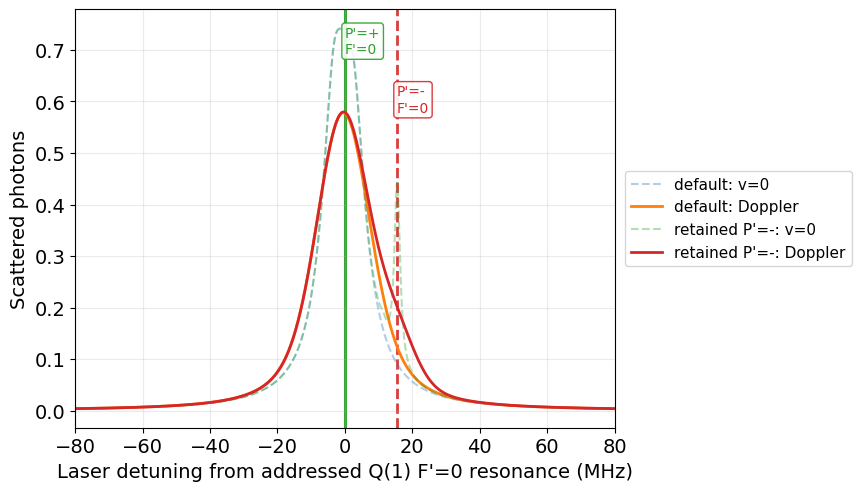

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

for name, scan in convolution_doppler_scans.items():
    x = scan["detuning_MHz"][visible_conv]
    ax.plot(
        x,
        scan["zero_velocity_photons"][visible_conv],
        "--",
        alpha=0.35,
        label=f"{DISPLAY_LABELS[name]}: v=0",
    )
    ax.plot(
        x,
        scan["photons"][visible_conv],
        lw=2,
        label=f"{DISPLAY_LABELS[name]}: Doppler",
    )

add_q1_level_markers(ax)
ax.set_xlim(*CONV_PLOT_LIMITS_MHZ)
ax.set_xlabel("Laser detuning from addressed Q(1) F'=0 resonance (MHz)")
ax.set_ylabel("Scattered photons")
ax.grid(alpha=0.25)
side_legend(ax)


## Notes

- The default builder remains backwards compatible because the additional level is not retained unless `retain_opposite_parity_levels=True`.
- The 15.42 MHz offset is close enough to be worth checking, but this comparison keeps the laser on resonance with the addressed Q(1) F'=0 transition.
- For transverse Doppler averaging, use the convolution section as the preferred full-range result; the direct velocity-quadrature section is kept as a diagnostic for convergence checks.
- Follow-up scans can vary detuning, electric field, and power to map where the retained level changes the observable population.
